In [3]:
import pymc as pm, pytensor, sys, platform
print("PyMC:", pm.__version__)
print("PyTensor:", pytensor.__version__)
print("Python:", sys.version)
print("Platform:", platform.platform())


PyMC: 5.25.1
PyTensor: 2.31.7
Python: 3.10.16 (main, Dec 11 2024, 10:24:41) [Clang 14.0.6 ]
Platform: macOS-10.16-x86_64-i386-64bit


# Probabilistic Programming via PyMC

As mentioned multiple times in class, Bayesian inference is nothing but probability theory. In every problem of Bayesian inference, there is a probability model for all the variables involved (data and parameters). The goal is to calculate the probability distribution of the unknowns given the observed variables. There are a bunch of libraries (in languages such as Python and R) whose aim is to ouput the required probability distribution given the model. Typically the output is in form of Monte Carlo samples from the required probability distribution. We shall focus on one of these libraries called PyMC in this course. This lab section will be a simple introduction to PyMC.

## Example One: PyMC for Simple Probability Calculations

To illustrate probabilistic programming with PyMC, consider the following simple probability model. We have four binary random variables: overweight, smoking, heart disease and cough. Suppose we specify a probability model for these random variables as:
\begin{align*}
   & \text{overweight} \sim \text{Bernoulli}(0.1) \\
   & \text{smoking} \sim \text{Bernoulli}(0.1) \\
   & \text{heart disease} \mid \text{overweight} = 1, \text{smoking} = 1 \sim \text{Bernoulli}(0.75) \\
   & \text{heart disease} \mid \text{overweight} = 1, \text{smoking} = 0 \sim \text{Bernoulli}(0.5) \\
   & \text{heart disease} \mid \text{overweight} = 0, \text{smoking} = 1 \sim \text{Bernoulli}(0.4) \\
   & \text{heart disease} \mid \text{overweight} = 0, \text{smoking} = 0 \sim \text{Bernoulli}(0.1) \\
   & \text{cough} \mid \text{smoking} = 1 \sim \text{Bernoulli}(0.6) \\
   & \text{cough} \mid \text{smoking} = 0 \sim \text{Bernoulli}(0.05)
\end{align*}
The above model starts by specifying the marginal distribution of overweight and smoking. Then it specifies the conditional distribution of heart disease conditional on overweight and smoking. Finally, it specifies the conditional distribution of cough conditional on smoking. Based on this model, we might be interested in several probability questions such as:
1. What is the marginal distribution of heart disease i.e., $\mathbb{P}(\text{heart disease} = 1)$?
2. What is the conditional distribution of overweight conditional on heart disease i.e., $\mathbb{P}(\text{overweight} = 1 \mid \text{heart disease} = 1)$?
3. What is conditional distribution of smoking conditional on cough i.e., $\mathbb{P}(\text{smoking} = 1 \mid \text{cough} = 1)$?

All these probabilities can be calculated exactly using the model specification. One way of doing this is to note that for every binary $b_o, b_s, b_h, b_c \in \{0, 1\}$, we can write
\begin{align*}
  &\mathbb{P}\left(\text{overweight} = b_o, \text{smoking} = b_s, \text{heart} = b_h, \text{cough} = b_c \right) \\
  &= \mathbb{P}\left(\text{overweight} = b_o \right) \mathbb{P}\left(\text{smoking} = b_s \right) \mathbb{P} \left(\text{heart} = b_h \mid \text{overweight} = b_o, \text{smoking} = b_s \right) \mathbb{P} \left(\text{cough} = b_c \mid \text{smoking} = b_s \right)
\end{align*}
and these probabilities can then be read off from the model specification. For example, with $b_o = b_s = b_h = b_c = 1$, we get
\begin{align*}
    &\mathbb{P}\left(\text{overweight} = 1, \text{smoking} = 1, \text{heart} = 1, \text{cough} = 1 \right) \\
    &= \mathbb{P}\left(\text{overweight} = 1 \right) \mathbb{P}\left(\text{smoking} = 1 \right) \mathbb{P} \left(\text{heart} = 1 \mid \text{overweight} = 1, \text{smoking} = 1 \right) \mathbb{P} \left(\text{cough} = 1 \mid \text{smoking} = 1 \right) \\
    &= 0.1 \times 0.1 \times 0.75 \times 0.6
\end{align*}
From the full joint distribution of the four variables, all the probabilities asked in the questions can be calculated.

It is clear that this approach will be quite tedious especially if we are dealing with more than four random variables. Probabilistic Programming Libraries (such as PyMC) automate the calculation of these probabilities. However, instead of calculating probabilities exactly, they output "samples" from which probabilities can be approximated. Here is how this works for this simple health probability model.

In [1]:
#Import the necessary libraries:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
#ignore any warnings that you may get about ArviZ; we will not be using ArviZ much

Here is how we specify the model in PyMC.

In [ ]:
#Specify the Model in PyMC:
health_model = pm.Model()
with health_model:
    
    overweight = pm.Bernoulli('overweight', 0.1)
    smoking = pm.Bernoulli('smoking', 0.1)
    # Deterministic probabilities for 'heart' based on conditions
    p_heart = pm.Deterministic('p_heart', pm.math.switch(overweight,
                                      pm.math.switch(smoking, 0.75, 0.5),
                                      pm.math.switch(smoking, 0.4, 0.1))) #pm.math.switch(smoking, 0.75, 0.5) simply returns 0.75 if smoking is 1 and 0.5 if smoking is 0.

    # 'heart' random variable
    heart = pm.Bernoulli('heart', p_heart)
    # Deterministic probability for 'cough' based on 'smoking'
    p_cough = pm.Deterministic('p_cough', pm.math.switch(smoking, 0.6, 0.05))
    # 'cough' random variable
    cough = pm.Bernoulli('cough', p_cough)
    #This ends the specification of the model.
    #To obtain samples from PyMC, run the following:
    trace = pm.sample(5000, chains = 4, return_inferencedata = False)
    #This will generate 5000*4 = 20000 posterior samples from (overweight, smoking, heart, cough).
    #We only want samples and not the other information that PyMC returns, so we set return_inferencedata = False.

The above code runs an MCMC algorithm (we will study some of these algorithms later in the course), and generates draws from all the four variables overweight, smoking, heart, cough having the joint distribution specified by the model. The algorithms runs 4 Markov Chains each of length 5000 (some initial samples part of the burn-in period are automatically deleted by PyMC). Here is how the generated samples can be accessed.

In [ ]:
print(trace)
print(trace.varnames)

<MultiTrace: 4 chains, 5000 iterations, 6 variables>
['overweight', 'smoking', 'heart', 'cough', 'p_heart', 'p_cough']


So PyMC is thinking of this model as having six variables. The parameters $p_{\text{heart}}$ and $p_{\text{cough}}$ are also counted as variables. So PyMC will also generate samples from $p_{\text{heart}}$ and $p_{\text{cough}}$. But these samples are not very interesting because, according to the model specification, $p_{\text{heart}}$ is a deterministic function of the variables overweight and smoking, and $p_{\text{cough}}$ is a deterministic function of smoking. We will only focus on the samples drawn from the four variables overweight, smoking, heart and cough.

In [ ]:
print(trace)
overweight_samples = trace['overweight'].flatten()
smoking_samples = trace['smoking'].flatten()
heart_samples = trace['heart'].flatten()
cough_samples = trace['cough'].flatten()
all_samples = np.column_stack((overweight_samples, smoking_samples, heart_samples, cough_samples))
print(all_samples.shape)
#all_samples is a 20000 x 4 array where each row corresponds to a sample of (overweight, smoking, heart, cough)
#all samples from the four Markov chains are combined together in all_samples. The first column corresponds to overweight, the second to smoking, the third to heart, and the fourth to cough.
print(all_samples[:40])


<MultiTrace: 4 chains, 5000 iterations, 6 variables>
(20000, 4)
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [1 0 1 0]
 [0 0 0 0]
 [0 0 1 0]
 [1 0 0 0]
 [0 0 1 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [1 0 1 0]
 [0 1 1 0]
 [1 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 1]
 [0 0 0 0]
 [0 0 0 0]
 [0 1 0 0]
 [0 1 1 0]
 [0 0 0 0]
 [0 0 1 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


With these samples, the questions we posed previously can be answered. For example, the marginal distribution of heart disease can be calculated as:

In [ ]:
#Marginal probability that heart = 1:
print(np.sum(heart_samples)/len(heart_samples))

#This should be compared to the actual value of the probability which can be calculated (more tediously) as:
p_overweight = 0.1
p_smoking = 0.1
# Conditional probabilities for heart
p_heart_given_overweight_and_smoking = 0.75
p_heart_given_overweight_and_not_smoking = 0.5
p_heart_given_not_overweight_and_smoking = 0.4
p_heart_given_not_overweight_and_not_smoking = 0.1
# Calculate the marginal probability of heart being 1
p_heart = (
    p_overweight * p_smoking * p_heart_given_overweight_and_smoking +
    p_overweight * (1 - p_smoking) * p_heart_given_overweight_and_not_smoking +
    (1 - p_overweight) * p_smoking * p_heart_given_not_overweight_and_smoking +
    (1 - p_overweight) * (1 - p_smoking) * p_heart_given_not_overweight_and_not_smoking
)
print(p_heart)

0.1607
0.16950000000000004


The second question asked to calculate the conditional distribution of overweight conditional on heart disease i.e., $\mathbb{P}(\text{overweight} = 1 \mid \text{heart disease} = 1)$? We can again calculate this using the previous samples in the following. We only consider those samples for which heart = 1. Then we calculate the proportion of these samples where overweight also equals 1. This can be done as follows:

In [ ]:
#Calculating the conditional probability of overweight = 1 given heart = 1 from the posterior samples.
mask = (heart_samples == 1)
print(sum(mask)) #this means that many of the original samples are discarded for this calculation.
count_overweight_given_heart = sum(overweight_samples[mask] == 1)
required_probability = count_overweight_given_heart/sum(mask)
print(required_probability)

#Exact calculation
print((p_overweight * p_smoking * p_heart_given_overweight_and_smoking + p_overweight * (1 - p_smoking) * p_heart_given_overweight_and_not_smoking) / p_heart)

3214
0.3176726820161792
0.30973451327433627


Even though we had 20000 posterior samples to begin with, only about 3389 of them have heart disease equal to 1. This means that this probability is approximated based on only 3389 samples (as opposed to 20000). In PyMC, if you want to generate samples conditional on certain values (such as $\text{heart disease} = 1$ in the above example), one plugs this information into the model at the specification stage. This prevents the wastage of samples as above. This is illustrated below. The clause $\text{heart disease} = 1$ can be interpreted as having observed that $\text{heart disease} = 1$. So we input this as 'observed'.

In [ ]:
#PyMC model when heart is pre-specified as 1.
health_model_1 = pm.Model()
with health_model_1:
    overweight = pm.Bernoulli('overweight', 0.1)
    smoking = pm.Bernoulli('smoking', 0.1)
    # Deterministic probabilities for 'heart' based on conditions
    p_heart = pm.Deterministic('p_heart', pm.math.switch(overweight,
                                      pm.math.switch(smoking, 0.75, 0.5),
                                      pm.math.switch(smoking, 0.4, 0.1)))

    # 'heart' random variable
    heart = pm.Bernoulli('heart', p_heart, observed = 1)
    #observed = 1 means we want heart to be fixed at the observed value of 1.
    #If we want heart to be fixed at 0, we would say observed = 0.
    # Deterministic probability for 'cough' based on 'smoking'
    p_cough = pm.Deterministic('p_cough', pm.math.switch(smoking, 0.6, 0.05))
    # 'cough' random variable
    cough = pm.Bernoulli('cough', p_cough)
    #This ends the specification of the model.
    #To obtain samples from PyMC, run the following:
    trace = pm.sample(5000, chains = 4, return_inferencedata = False)
    #This will generate 5000*4 = 20000 posterior samples from (overweight, smoking, heart, cough).

In [ ]:
print(trace)
print(trace.varnames)

<MultiTrace: 4 chains, 5000 iterations, 5 variables>
['overweight', 'smoking', 'cough', 'p_heart', 'p_cough']


Note that heart is no longer considered as a variable that needs to be sampled from. Instead it is just set to 1. So the model only considers now 5 variables as opposed to 6 earlier.

In [ ]:
print(trace)
overweight_samples = trace['overweight'].flatten()
smoking_samples = trace['smoking'].flatten()
cough_samples = trace['cough'].flatten()
all_samples = np.column_stack((overweight_samples, smoking_samples, cough_samples))
print(all_samples.shape)
print(all_samples[:20])


<MultiTrace: 4 chains, 5000 iterations, 5 variables>
(20000, 3)
[[1 1 1]
 [0 1 1]
 [0 1 0]
 [0 1 1]
 [0 1 1]
 [0 0 1]
 [0 0 0]
 [0 0 0]
 [1 0 0]
 [1 0 0]
 [0 0 0]
 [0 0 0]
 [1 0 0]
 [0 0 0]
 [1 0 0]
 [0 0 0]
 [1 0 0]
 [0 0 0]
 [1 0 0]
 [0 0 0]]


With these samples (conditioned on $\text{heart} = 1$), we can calculate the conditional probability of overweight given heart disease as:

In [ ]:
#Marginal probability that heart = 1:
print(np.sum(overweight_samples)/len(overweight_samples))

#Exact calculation
print((p_overweight * p_smoking * p_heart_given_overweight_and_smoking + p_overweight * (1 - p_smoking) * p_heart_given_overweight_and_not_smoking) / p_heart)

0.30795
True_div.0


In [ ]:
#PyMC model when cough is pre-specified as 1.
health_model_2 = pm.Model()
with health_model_2:
    overweight = pm.Bernoulli('overweight', 0.1)
    smoking = pm.Bernoulli('smoking', 0.1)
    # Deterministic probabilities for 'heart' based on conditions
    p_heart = pm.Deterministic('p_heart', pm.math.switch(overweight,
                                      pm.math.switch(smoking, 0.75, 0.5),
                                      pm.math.switch(smoking, 0.4, 0.1)))

    # 'heart' random variable
    heart = pm.Bernoulli('heart', p_heart)
    #observed = 1 means we want heart to be fixed at the observed value of 1.
    #If we want heart to be fixed at 0, we would say observed = 0.
    # Deterministic probability for 'cough' based on 'smoking'
    p_cough = pm.Deterministic('p_cough', pm.math.switch(smoking, 0.6, 0.05))
    # 'cough' random variable
    cough = pm.Bernoulli('cough', p_cough, observed = 1)
    #This ends the specification of the model.
    #To obtain samples from PyMC, run the following:
    trace = pm.sample(5000, chains = 4, return_inferencedata = False)
    #This will generate 5000*4 = 20000 posterior samples from (overweight, smoking, heart, cough).

In [ ]:
print(trace)
overweight_samples = trace['overweight'].flatten()
smoking_samples = trace['smoking'].flatten()
heart_samples = trace['heart'].flatten()
all_samples = np.column_stack((overweight_samples, smoking_samples, heart_samples))
print(all_samples.shape)
print(all_samples[:20])


<MultiTrace: 4 chains, 5000 iterations, 5 variables>
(20000, 3)
[[0 0 0]
 [0 1 0]
 [0 0 0]
 [0 0 0]
 [0 1 0]
 [0 0 0]
 [0 1 1]
 [0 0 0]
 [0 0 0]
 [0 1 0]
 [0 0 0]
 [0 0 0]
 [0 1 1]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 1 1]
 [0 0 0]
 [0 1 0]
 [0 0 1]]


In [ ]:
#Required conditional probability:
print(np.sum(smoking_samples)/len(smoking_samples))

0.5742


Many problems we studied so far in class can be solved using PyMC. We provide some examples below.

## Example Two: Testing and COVID

Recall that this model had two variables $\text{Covid}$ and $\text{Test}$ and the model is:
\begin{align*}
   \mathbb{P} \left\{\text{Covid} = 1 \right\} = 0.02 ~~~ \text{and } ~~ \mathbb{P} \left\{\text{Test} = 1 \mid \text{Covid} = 1 \right\} = 0.99 ~~~ \text{ and } ~~~ \mathbb{P} \left\{\text{Test} = 1 \mid \text{Covid} = 0 \right\} = 0.04.
\end{align*}
We need to calculate $\mathbb{P}\{\text{Covid} = 1 \mid \text{Test} = 1\}$ which can be done via PyMC as follows.

In [ ]:
testcovid = pm.Model()
with testcovid:
    covid = pm.Bernoulli('covid', 0.02) #this is the prior
    test = pm.Bernoulli('test', pm.math.switch(covid, 0.99, 0.04), observed = 1) #this specifies the likelihood
    trace = pm.sample(5000, chains = 4, return_inferencedata=False)

In [ ]:
covid_samples = trace['covid'].flatten()
print(np.sum(covid_samples)/len(covid_samples))

0.33545


So the answer is 0.33395. Recall that we calculated this in class (via the Bayes rule) and we got 0.3356, so the sampling-based answer is reasonably close.

In Lab one, we studied the case of reproducibility of the positive test. So we introduced another variable test2 into the model:
$$\mathbb{P}\{\text{Second Test}=1 \mid \text{First Test} = 1 \}=?$$
The model now becomes:

In [ ]:
covid2tests = pm.Model()
with covid2tests:
    covid = pm.Bernoulli('covid', 0.02)
    test1 = pm.Bernoulli('test1', pm.math.switch(covid, 0.99, 0.04), observed = 1)
    test2 = pm.Bernoulli('test2', pm.math.switch(covid, 0.99, 0.04))
    trace = pm.sample(5000, chains = 4, return_inferencedata=False)

In [ ]:
test2_samples = trace['test2'].flatten()
print(np.sum(test2_samples)/len(test2_samples))

0.36645


This is reasonably close to the exact answer 0.35882 (calculated in Lab 1).

## Example Three: Inference from measurements

Suppose a scientist makes 6 numerical measurements 26.6, 38.5, 34.4, 34, 31, 23.6 on an unknown real-valued physical quantity $\theta$. On the basis of these measurements, what can be inferred about $\theta$?

Input the data as below.

In [ ]:
y_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6])
n = len(y_obs)
print(n)

6


We then specify the model. We are using 'pm.Flat' to indicate the uniform prior on $-\infty$ to $\infty$.

In [ ]:
measurement_model = pm.Model()
with measurement_model:
    theta = pm.Flat("theta")
    log_sigma = pm.Flat("log_sigma")
    sigma = pm.Deterministic("sigma", pm.math.exp(log_sigma))
    Y = pm.Normal("Y", mu = theta, sigma = sigma, observed=y_obs)
    #Sample from posterior:
    trace = pm.sample(2000, chains = 4, return_inferencedata = False)

The posterior samples for $\theta$ and $\sigma$ can be accessed as follows.

In [ ]:
theta_samples = trace['theta'].flatten()
sigma_samples = trace['sigma'].flatten()
print(theta_samples.shape)
print(sigma_samples.shape)

(8000,)
(8000,)


From these samples, we can answer any question about the unknown parameters. For example, we can obtain uncertainty (credible) intervals for them as follows.

In [ ]:
#95% interval for theta based on the posterior samples is computed as follows:
lower_limit_theta = np.percentile(theta_samples, 2.5)
upper_limit_theta = np.percentile(theta_samples, 97.5)
print(np.array([lower_limit_theta, upper_limit_theta]))

#95% interval for sigma based on the posterior samples is computed as follows:
lower_limit_sigma = np.percentile(sigma_samples, 2.5)
upper_limit_sigma = np.percentile(sigma_samples, 97.5)
print(np.array([lower_limit_sigma, upper_limit_sigma]))

[25.61098059 36.98577036]
[ 3.40471576 13.04287808]


Recall that the 95\% interval that we got by exact calculation (based on the $t$-distribution) is $[25.598, 37.102]$. This is very close to the interval obtained from the MCMC samples above.

## Kidney Cancer Data

In [ ]:
#Read the kidney cancer dataset
import pandas as pd
d_full = pd.read_csv("KidneyCancerClean.csv", skiprows=4)
d = d_full[['state', 'Location', 'fips', 'dc', 'pop', 'dc.2', 'pop.2']].copy()
#Combine the death and population counts for the two periods 80-84 and 85-89
d['dct'] = d['dc'] + d['dc.2'] #dct stands for death count total
d['popm'] = (d['pop'] + d['pop.2']) / 2
#Define N, x, and n
N = len(d)
x = d['dct'].values
n = d['popm'].values

To this dataset, we will fit the (Bayesian) model:
\begin{align*}
   \log a, \log b \overset{\text{i.i.d}}{\sim} \text{uniform}(-\infty, \infty) ~~ \text{ and } ~~ \theta_i \mid a, b \overset{\text{i.i.d}}{\sim} Beta(a, b)  ~~ \text{ and } ~~ X_i \overset{\text{ind}}{\sim} Bin(n_i, \theta_i).
\end{align*}
This model is input in PyMC by the following code.

In [ ]:
kidney_model = pm.Model()
with kidney_model:
    log_a = pm.Flat("log_a")
    log_b = pm.Flat("log_b")
    a = pm.Deterministic("a", pm.math.exp(log_a))
    b = pm.Deterministic("b", pm.math.exp(log_b))
    theta = pm.Beta("theta", alpha=a, beta=b, shape = N)
    Y = pm.Binomial("Y", n=n, p=theta, observed=x)
    #Sample from posterior:
    trace = pm.sample(1000, chains = 4, return_inferencedata = False)

The obtained MCMC samples can be used to answer all questions about the parameters. If we want a point estimate of the kidney cancer death rate for county $i$, we can simply take the mean of the posterior samples for $\theta_i$.

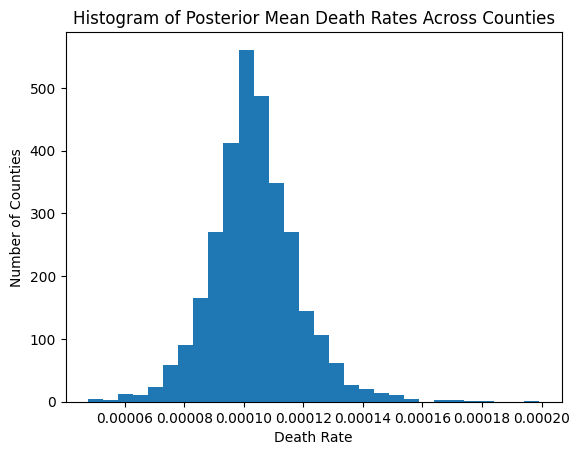

In [ ]:
theta_samples = trace.get_values("theta")
theta_post_mean = theta_samples.mean(axis=0)
#histogram of death rates across counties:
plt.hist(theta_post_mean, bins = 30)
plt.xlabel("Death Rate")
plt.ylabel("Number of Counties")
plt.title("Histogram of Posterior Mean Death Rates Across Counties")
plt.show()

If we are interested in a particular county $i$, we can look at all the posterior samples of $\theta_i$ for that value of $i$.

In [ ]:
#Consider the county in row 1681 of the dataset:
i = 1681
print(d.iloc[i])


state                         NEBRASKA
Location    McPherson County, Nebraska
fips                             31117
dc                                   0
pop                               1504
dc.2                                 1
pop.2                             1392
dct                                  1
popm                            1448.0
Name: 1681, dtype: object


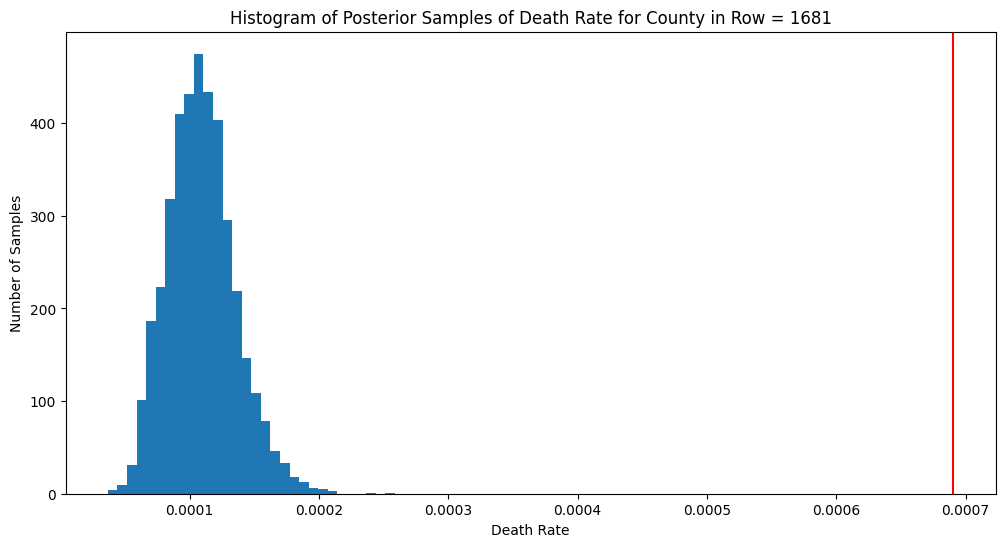

In [ ]:
#Histogram of theta_i samples for this county:
plt.figure(figsize = (12, 6))
plt.hist(theta_samples[:, i], bins = 30)
plt.xlabel("Death Rate")
plt.ylabel("Number of Samples")
plt.axvline(x = d.iloc[i]['dct']/d.iloc[i]['popm'], color = 'red', label = "Naive Estimate")
plt.title(f"Histogram of Posterior Samples of Death Rate for County in Row = {i}")
plt.show()


The red vertical represents the proportion of kidney cancer deaths in this county. Because this county has a low population, the posterior distribution of $\theta_i$ is very different from the proportion.

state                      NEBRASKA
Location    Arthur County, Nebraska
fips                          31005
dc                                0
pop                            1295
dc.2                              0
pop.2                          1172
dct                               0
popm                         1233.5
Name: 1624, dtype: object


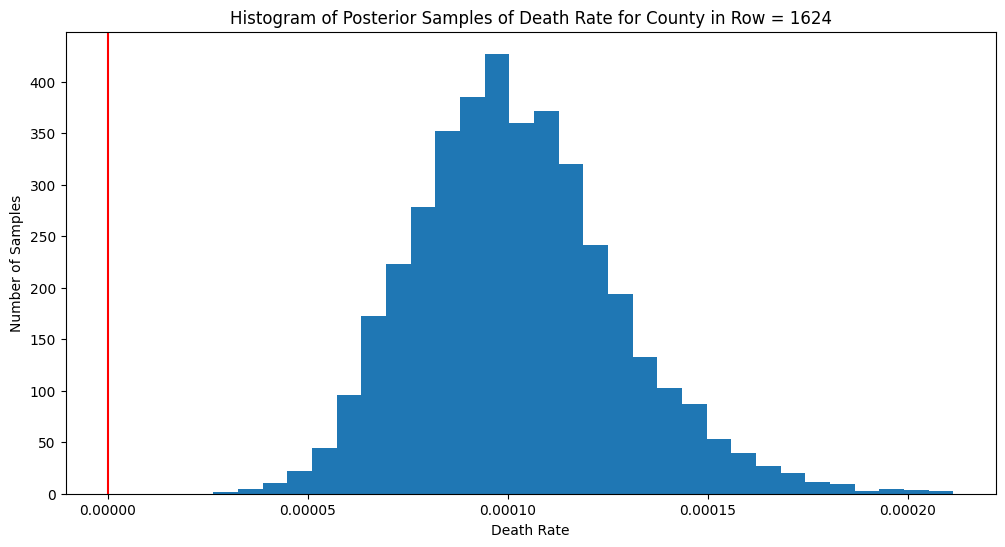

In [ ]:
#Repeat with a different i:
i = 1624
print(d.iloc[i]) #another low population county

#Histogram of theta_i samples for this county:
plt.figure(figsize = (12, 6))
plt.hist(theta_samples[:, i], bins = 30)
plt.xlabel("Death Rate")
plt.ylabel("Number of Samples")
plt.axvline(x = d.iloc[i]['dct']/d.iloc[i]['popm'], color = 'red', label = "Naive Estimate")
plt.title(f"Histogram of Posterior Samples of Death Rate for County in Row = {i}")
plt.show()



state                        FLORIDA
Location    Sarasota County, Florida
fips                           12115
dc                                55
pop                           485595
dc.2                              65
pop.2                         573711
dct                              120
popm                        529653.0
Name: 346, dtype: object


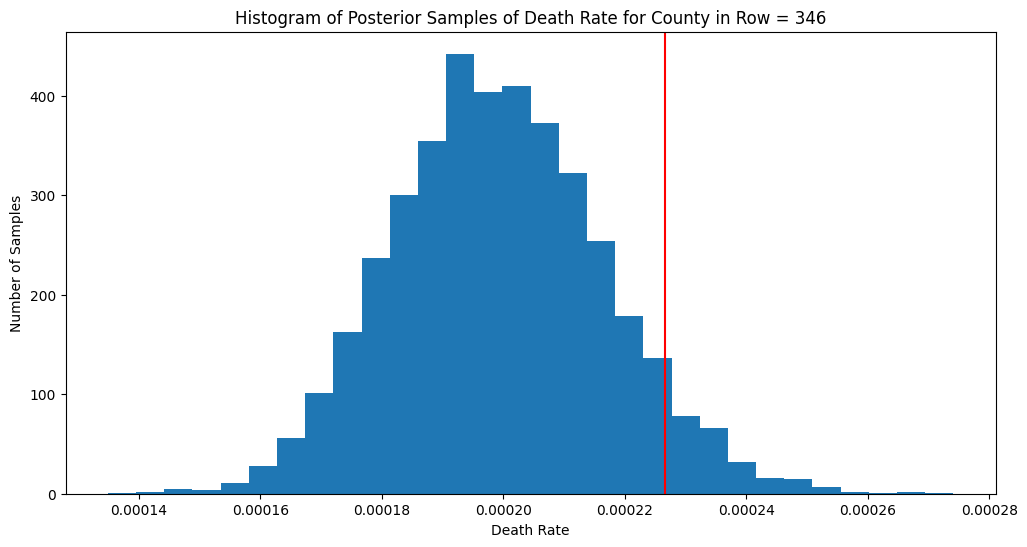

In [ ]:
#Next we shall look at a high-population county:
#Repeat with a different i:
i = 346
print(d.iloc[i]) #another low population county

#Histogram of theta_i samples for this county:
plt.figure(figsize = (12, 6))
plt.hist(theta_samples[:, i], bins = 30)
plt.xlabel("Death Rate")
plt.ylabel("Number of Samples")
plt.axvline(x = d.iloc[i]['dct']/d.iloc[i]['popm'], color = 'red', label = "Naive Estimate")
plt.title(f"Histogram of Posterior Samples of Death Rate for County in Row = {i}")
plt.show()



Here we see that the posterior is much closer to the actual proportion of deaths.

We can use the posterior mean estimates of $\theta_i$ to rank the counties with high kidney cancer death rates.

In [ ]:
threshold = pd.Series(theta_post_mean).nlargest(100).iloc[-1]
d['bayeshigh'] = theta_post_mean >= threshold


Below are the flagged counties. It is easy to see that the list mainly includes counties with large populations.

In [ ]:
with pd.option_context('display.max_rows', None):
    display(d[d['bayeshigh'] >= True])

,state,Location,fips,dc,pop,dc.2,pop.2,dct,popm,bayeshigh
61,ALABAMA,"Tallapoosa County, Alabama",1123,8,67871,7,68002,15,67936.5,True
71,ARIZONA,"Graham County, Arizona",4009,7,51342,6,53873,13,52607.5,True
74,ARIZONA,"Mohave County, Arizona",4015,8,149437,22,189941,30,169689.0,True
79,ARIZONA,"Yavapai County, Arizona",4025,14,176766,21,223856,35,200311.0,True
106,ARKANSAS,"Garland County, Arkansas",5051,10,154925,18,158622,28,156773.5,True
148,ARKANSAS,"Sharp County, Arkansas",5135,4,34922,5,33806,9,34364.0,True
172,CALIFORNIA,"Lake County, California",6033,12,93785,11,109600,23,101692.5,True
183,CALIFORNIA,"Napa County, California",6055,13,236568,29,247143,42,241855.5,True
280,CONNECTICUT,"Middlesex County, Connecticut",9007,20,304656,35,320284,55,312470.0,True
294,FLORIDA,"Broward County, Florida",12011,197,2212734,207,2381166,404,2296950.0,True


In [ ]:
#Look at the states for the high counties
counts = d.groupby('state').agg({'bayeshigh': 'sum'})
print(counts)

                      bayeshigh
state                          
ALABAMA                       1
ARIZONA                       3
ARKANSAS                      2
CALIFORNIA                    2
COLORADO                      0
CONNECTICUT                   1
DELAWARE                      0
DISTRICT.OF.COLUMBIA          0
FLORIDA                      14
GEORGIA                       0
HAWAII                        0
IDAHO                         0
ILLINOIS                      7
INDIANA                       2
IOWA                          5
KANSAS                        3
KENTUCKY                      1
LOUISIANA                     3
MAINE                         0
MARYLAND                      1
MASSACHUSETTS                 1
MICHIGAN                      4
MINNESOTA                     7
MISSISSIPPI                   0
MISSOURI                      6
MONTANA                       0
NEBRASKA                      1
NEVADA                        0
NEW.HAMPSHIRE                 0
NEW.JERS

The bayeshigh counties are highly concentrated in a small number of states rather than being spread evenly across the country. Florida stands out as a clear outlier with 14 high-Bayes counties, followed by Pennsylvania (8) and Minnesota (7). A second tier consists mainly of Midwestern states—Illinois, Iowa, and Missouri (6 each) and Wisconsin (5)—with additional moderate contributions from Michigan, Oklahoma, and Texas (4 each). Many states have only one or two flagged counties, and a large fraction of states have none at all, indicating strong geographic clustering, particularly in Florida and the Midwest, rather than a nationwide pattern.

Here is a plot of the high rate counties on the US map.

In [ ]:
#Plotting counties with high Bayesian estimates of kidney cancer rates on the US map
import plotly.express as px
#First convert fips to standard form:
d['modfips'] = d['fips'].apply(lambda x: str(x).zfill(5))
#Plotting the counties with high cancer proportion:

fig = px.choropleth(
    d,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json", # This is a dataset containing county geometries
    locations='modfips', # Use the 'fips' column for county identification
    color='bayeshigh',
    hover_name='Location',  # Display the 'Location' column on hover
    scope="usa",
    title="Top 100 kidney cancer death rate counties (in terms of Bayes estimates)",
    color_continuous_scale="YlOrRd"
)
fig.update_geos(fitbounds="locations")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

Note that this analysis does not pre-determine $a$ and $b$ but instead treats them as unknown parameters that are learned from the data (via their posteriors). The posterior distributions of $a$ and $b$ can be plotted as histograms below.

In [ ]:
a_samples = trace.get_values("a")
a_postmean = np.mean(a_samples)
print(a_postmean)

b_samples = trace.get_values("b")
b_postmean = np.mean(b_samples)
print(b_postmean)

15.728135300552351
151790.57458820866


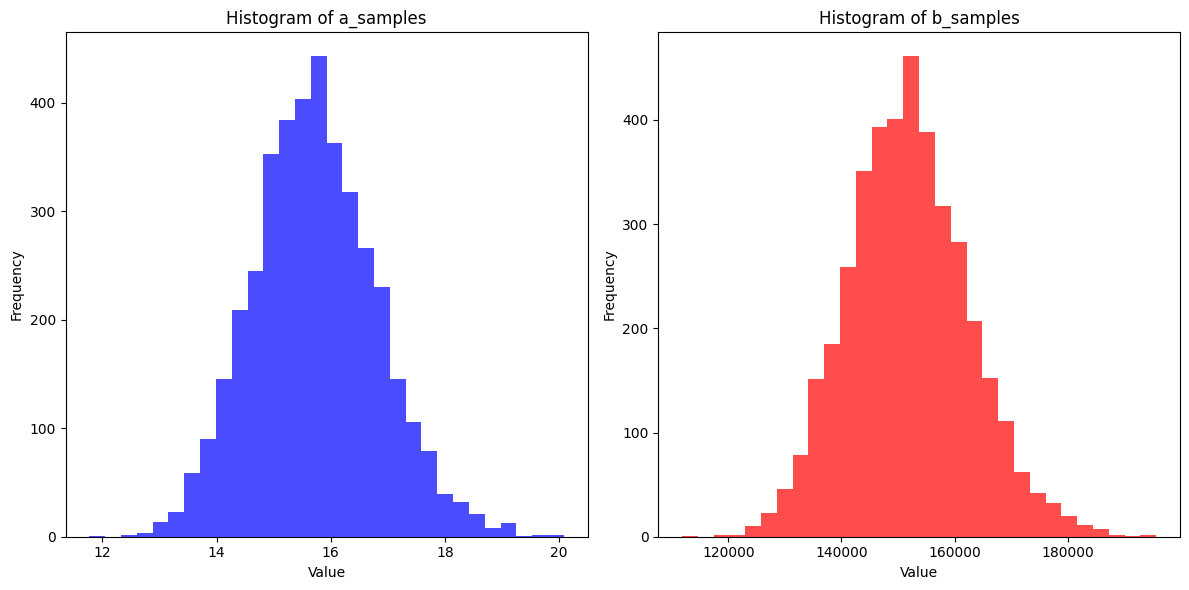

In [ ]:
#plotting the histograms of a_samples and b_samples
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].hist(a_samples, bins=30, color='blue', alpha=0.7, label='a_samples')
axes[0].set_title('Histogram of a_samples')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(b_samples, bins=30, color='red', alpha=0.7, label='b_samples')
axes[1].set_title('Histogram of b_samples')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The most interesting part of this analysis is that the model does not specify that $a$ should be small and $b$ should be large. The prior just uses flat priors for $\log a$ and $\log b$. However, probability theory (Bayesian inference) is able to figure that $a$ should be small and $b$ should be large, which is reflected in their posteriors.